## GDP per Capita and Government Spending

The data set `gdp2019` contains the GDP per capita in current prices for 142 countries in 2019. In addition, the variable `spending` shows the government spending in these countries as a share (in percent) of GDP.

-   `gdppc` (numeric): [GDP per capita](https://www.imf.org/external/datamapper/NGDPDPC@WEO/OEMDC/ADVEC/WEOWORLD) in USD (current prices)
-   `spending` (numeric): [Government spending as a share of GDP](https://www.imf.org/external/datamapper/exp@FPP/USA/FRA/JPN/GBR/SWE/ESP/ITA/ZAF/IND).

The data set was constructed using data from the IFM. You can find more information about the two variables by following the links above.

We want to explore the relationship between `gdppc` and `spending`.

In [3]:
library(tidyverse)

gdp2019 <- read_csv(
  "https://raw.githubusercontent.com/feb-sofia/econometrics-2023/main/data/gdpgov2019.csv"
  ) |>
  filter(!is.na(spending))
  
gdp2019 |> head()

Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ──────────────────────────────────────

country,year,gdppc,spending
<chr>,<dbl>,<dbl>,<dbl>
Albania,2019,5345.058,29.15313
Algeria,2019,3953.402,41.78414
Angola,2019,2612.246,20.40298
Antigua and Barbuda,2019,17495.760,22.61898
Argentina,2019,10054.023,37.70266
Aruba,2019,30850.838,23.20869


1.  Create a scatterplot for the two variables and add the estimated regression line for the model

$$
\text{gdppc}_i = \beta_0 + \beta_1 \text{spending}_i + e_i, \quad e_i \sim N(0, \sigma^2)
$$


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_smooth()`).”


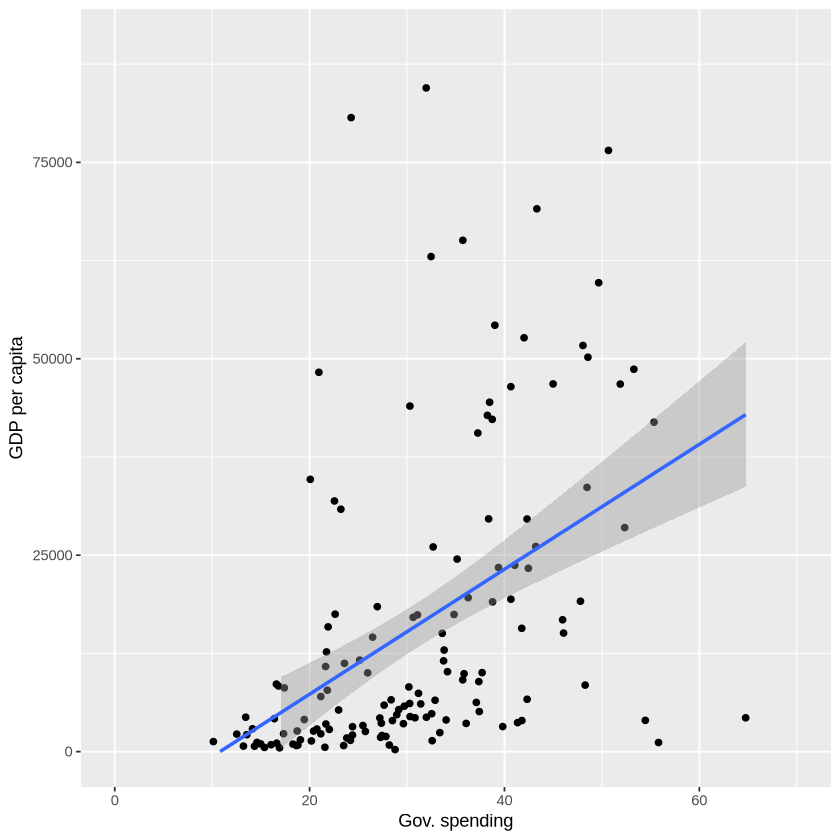

In [4]:
gdp2019 |>
  ggplot(aes(x = spending, y = gdppc)) +
  geom_point() +
  geom_smooth(method = "lm") +
  labs(
    y = "GDP per capita",
    x = "Gov. spending"
  ) +
  lims(
    x = c(0, 70),
    y = c(0, 90000)
  )

In [ ]:
# Estimate the model


2.  Create a new variable called `gdppc_gr` that has five categories:

-   Low: if $\text{gdppc} \leq 1025$
-   Medium-low: if $1025 < \text{gdppc} \leq 3995$
-   Medium-high: if $3995 < \text{gdppc} \leq 12375$
-   High: if $12375 < \text{gdppc} \leq 30000$
-   Very high: if $\text{gdppc} > 30000$

In [5]:
gdp2019 <- gdp2019 |>
  mutate(
    gdppc_gr = cut(
      gdppc,
      breaks = c(0, 3995, 20000, Inf),
      labels = c("Low", "Medium", "High"))
  )

table(gdp2019$gdppc_gr)


   Low Medium   High 
    49     57     36 

In [9]:
lm(gdppc ~ spending * gdppc_gr, data = gdp2019) |> summary()


Call:
lm(formula = gdppc ~ spending * gdppc_gr, data = gdp2019)

Residuals:
   Min     1Q Median     3Q    Max 
-23596  -3589   -539   1649  66789 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)              1702.29    2695.67   0.631    0.529    
spending                   11.30      84.05   0.134    0.893    
gdppc_grMedium           4639.67    5648.73   0.821    0.413    
gdppc_grHigh            41526.81    8222.03   5.051 1.39e-06 ***
spending:gdppc_grMedium   103.35     174.44   0.592    0.555    
spending:gdppc_grHigh      75.86     209.30   0.362    0.718    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 10680 on 136 degrees of freedom
Multiple R-squared:  0.7461,	Adjusted R-squared:  0.7368 
F-statistic: 79.94 on 5 and 136 DF,  p-value: < 2.2e-16


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


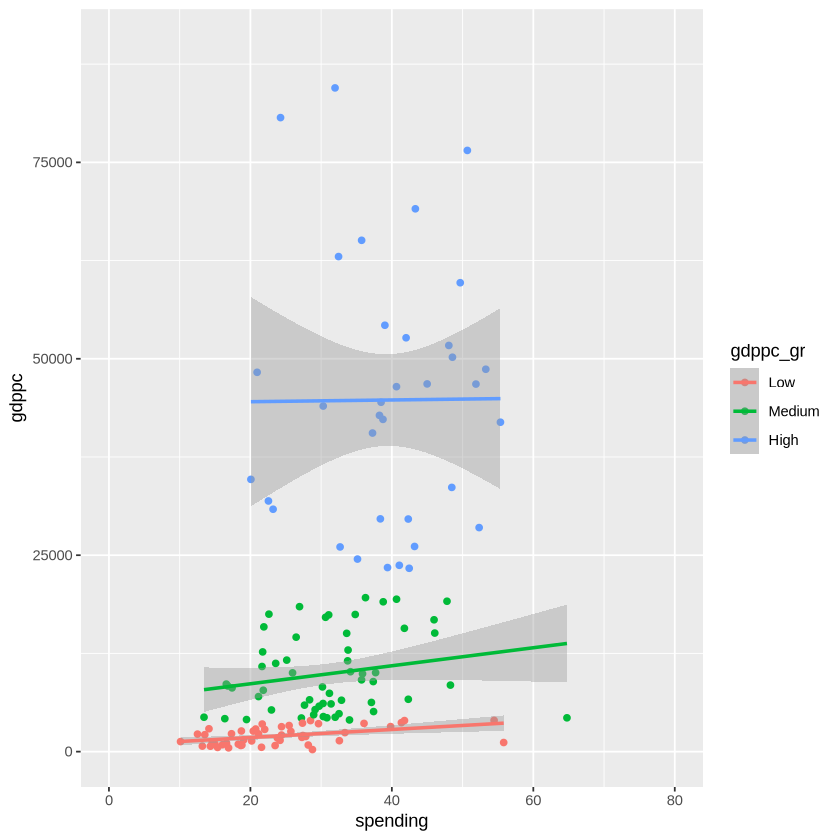

In [11]:
gdp2019 %>%
  ggplot(aes(x = spending, y = gdppc, color = gdppc_gr)) +
  geom_point() +
  geom_smooth(method = "lm") +
  # geom_abline(
  #   intercept = c(-144.39, 1308.32, 5835.94, 18460.21, 51920.69),
  #   slope = 44.80,
  #   alpha = 0.5
  # ) +
  lims(
    x = c(0, 80),
    y = c(0, 90000)
  )

## F-Test

Very often we want test the hypothesis that a certain subset of the coefficients are simultaneously equal to zero. This is called a joint hypothesis.

In our example we could test the hypothesis that the coefficients of `Med Low`, `Med High`, `High` and `Very High` are all equal to zero. This is equivalent to testing if the average of `gdppc` is the same in all groups.

The test is called an F-test and is based on the ratio of the sum of squared errors of the restricted model and the sum of squared errors of the unrestricted model.

The restricted model is the one where the coefficients of `Med Low`, `Med High`, `High` and `Very High` are all equal to zero.

The unrestricted model is the one where all coefficients are estimated.

The F-test is based on the following statistic:

$$
F = \frac{(RSS_{\text{restricted}} - RSS_{\text{unrestricted}}) / (p_{\text{restricted}} - p_{\text{unrestricted}})}{RSS_{\text{unrestricted}} / (n - p_{\text{unrestricted}})}
$$

$$
F = \frac{(RSS_{\text{restricted}} - RSS_{\text{unrestricted}})}{RSS_{\text{unrestricted}}}\frac{(n - p_{\text{unrestricted}})}{(p_{\text{restricted}} - p_{\text{unrestricted}})}
$$

where $RSS$ is the residual sum of squares, $p$ is the number of parameters in the model and $n$ is the number of observations.

## R Square

